In [1]:
import random

import awkward as ak
import hist
import matplotlib.pyplot as plt
import uproot


In [2]:
string = "ASDF ASDF E"

"ASDF" in string

True

In [4]:
file_list_2016 = [line.strip("\n") for line in open("filelists/run2_samples.txt") if "Run2016" in line]
file_list_2016 = ["root://cmseos.fnal.gov//store/user/lpcmultijets/abhijith/output3/output3/" + string for string in file_list_2016]
file_list_2017 = [line.strip("\n") for line in open("filelists/run2_samples.txt") if "Run2017" in line]
file_list_2017 = ["root://cmseos.fnal.gov//store/user/lpcmultijets/abhijith/output3/output3/" + string for string in file_list_2017]
file_list_2018 = [line.strip("\n") for line in open("filelists/run2_samples.txt") if "Run2018" in line]
file_list_2018 = ["root://cmseos.fnal.gov//store/user/lpcmultijets/abhijith/output3/output3/" + string for string in file_list_2018]

In [5]:
len(file_list_2016)

38905

In [6]:
f = uproot.concatenate(file_list_2016[0:1000])

In [7]:
overallcut= (f.ak4_HT > 500) & (f.jmds6332 < 1.25)
good_ev = f[overallcut]
cut = (good_ev.jtrip_masym < 0.15) & (good_ev.jtrip_mds < 0.175) & (good_ev.jtrip_delta > 250)
mass = good_ev.jtrip_mass[cut]

In [31]:
h_mass = (
            hist.Hist.new
            .StrCat(["Single","Multi"], growth=True, name="cuts")
            .Reg(1000, 100, 2000, name="mass", label="Trijet Invariant Mass")
            .Weight()
        )

In [33]:
for part in mass:
    if len(part) == 0:
        continue
    if len(part) == 1:
        h_mass.fill(mass=part[0],cuts="Single")
    else:
        h_mass.fill(mass=part,cuts="Multi")

In [24]:
h = h_mass["Single",:] + h_mass["Multi",:]

In [34]:
import mplhep as hep
hep.style.use("CMS")

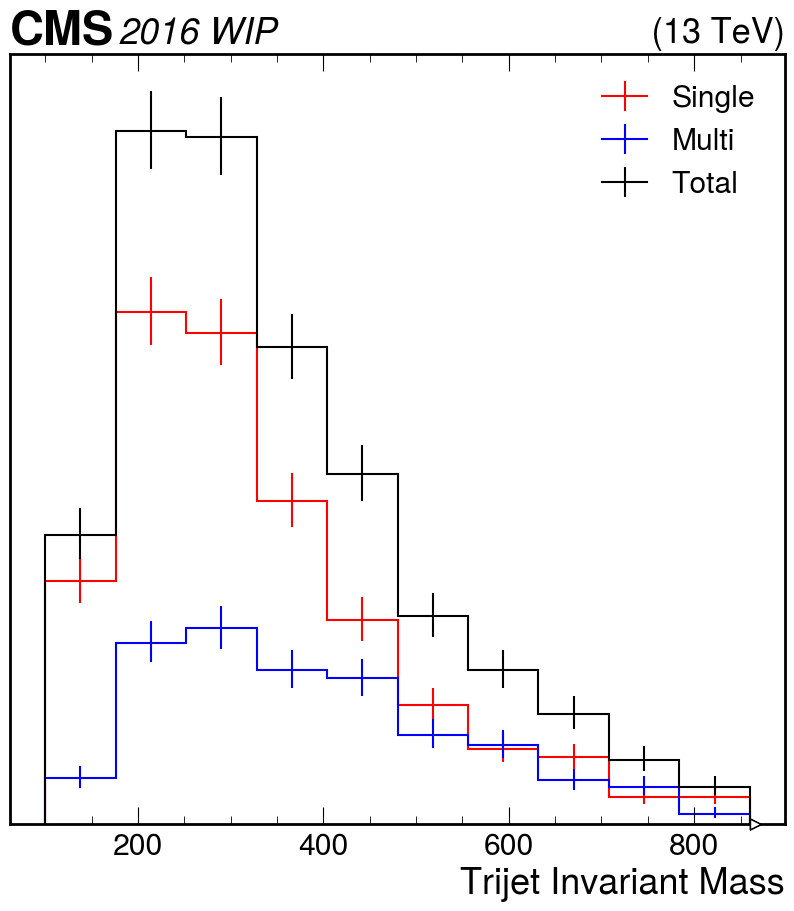

In [41]:
h = h_mass["Single",:] + h_mass["Multi",:]

h_mass["Single",0:410:40j].plot(color="red",label="Single")
h_mass["Multi",0:410:40j].plot(color="blue",label="Multi")
h[0:410:40j].plot(color="black",label="Total")
hep.cms.label(label="2016 WIP",data="Yes")
plt.yticks(ticks=[])
plt.legend()